# <font color="red">**H7: EELS Clustering Challenge**</font>

## Spectral data → EELS clustering and dimensional reduction

An EELS spectrum contains many energy channels, so every pixel can be viewed as a point in a **high-dimensional spectral space**.

Today we will ask:

> **Can we find meaningful groups of EELS spectra, and do we recover the same groups after reducing the dimensionality?**

### Your tasks

1. Explore the EELS spectral dataset.
2. Cluster spectra in the **original high-dimensional space**.
3. Reduce the spectra with **PCA**.
4. Cluster again in the **low-dimensional PCA space**.
5. Compare the two cluster maps.
6. Measure how strongly the cluster assignments overlap.
7. Decide what makes a clustering result **good or bad**.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kbarakati/athena_camm_hackathon/blob/k4my4r/docs/day_18_25092026/eels_clustering_hackathon.ipynb)

<h2><font color="purple">1.</font> Load the Dataset</h2>

<p>
Each spatial pixel contains one complete <b>EELS spectrum</b>.
</p>

<p style="font-size:18px;">
(x, y) &rarr; I(E)
</p>

<p>
If the spectral image has dimensions:
</p>

<p style="font-size:18px;">
H &times; W &times; N<sub>E</sub>
</p>

<p>
then:
</p>

<ul>
  <li><b>H</b> = image height</li>
  <li><b>W</b> = image width</li>
  <li><b>N<sub>E</sub></b> = number of energy channels in each spectrum</li>
</ul>

<p>
Therefore, every spatial pixel contains <b>N<sub>E</sub> spectral features</b>.
</p>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
)
from sklearn.metrics.cluster import contingency_matrix

In [ ]:
# Download data in Google Colab
!gdown --fuzzy 1FKmlRTRDImQS91V4YQjcQHoJU19X6P_6

Downloading...
From (original): https://drive.google.com/uc?id=1FKmlRTRDImQS91V4YQjcQHoJU19X6P_6
From (redirected): https://drive.google.com/uc?id=1FKmlRTRDImQS91V4YQjcQHoJU19X6P_6&confirm=t&uuid=0675e863-ab6f-4cc6-9d45-cad53ac453ef
To: /content/Plasmonic_sets_hackathon.npy
100% 584M/584M [00:04<00:00, 136MB/s]


In [ ]:
file_name = "/content/Plasmonic_sets_hackathon.npy"

raw = np.load(file_name, allow_pickle=True)
loadedfile = raw.tolist()

print("Available datasets:", loadedfile.keys())

Available datasets: dict_keys(['0', '1', '2', '3'])


In [ ]:
# Use the same dataset as the previous challenge
data = loadedfile["2"]

image = data["image"]
spectra = data["spectrum image"]
energy = data["energy axis"]

H, W, N_E = spectra.shape

print("Image:", image.shape)
print("Spectral image:", spectra.shape)
print("Energy axis:", energy.shape)

Image: (33, 63)
Spectral image: (33, 63, 4322)
Energy axis: (4322,)


## <font color="purple">**2.**</font> Explore the Spectra

Before clustering, always look at the data.

The structural image tells us **where** each spectrum was measured.  
The spectra tell us **what the local EELS response looks like**.

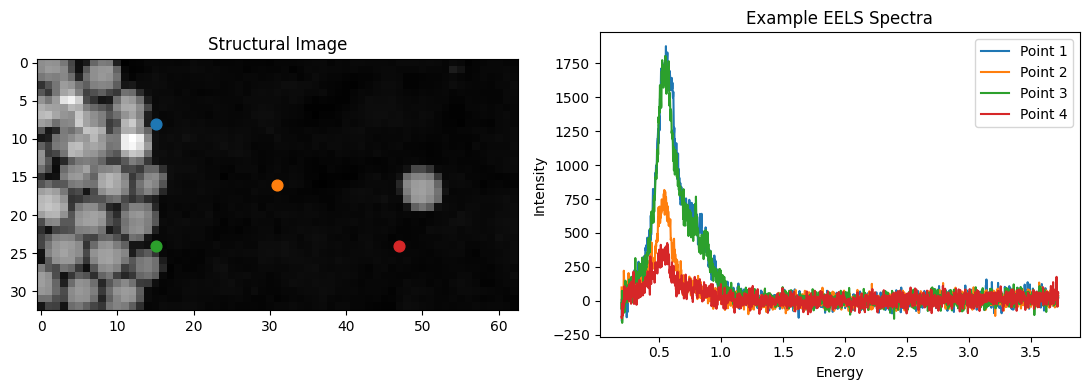

In [ ]:
# Pick a few example locations
positions = [
    (H // 4, W // 4),
    (H // 2, W // 2),
    (3 * H // 4, W // 4),
    (3 * H // 4, 3 * W // 4),
]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].imshow(image, cmap="gray")
ax[0].set_title("Structural Image")

for i, (y, x) in enumerate(positions):
    ax[0].scatter(x, y, s=60)
    ax[1].plot(energy, spectra[y, x], label=f"Point {i + 1}")

ax[1].set_title("Example EELS Spectra")
ax[1].set_xlabel("Energy")
ax[1].set_ylabel("Intensity")
ax[1].legend()

plt.tight_layout()
plt.show()

## <font color="purple">**3.**</font> Convert the Spectral Image into a Data Matrix

Clustering algorithms expect a table:

- **rows** = samples
- **columns** = features

For EELS:

- one **pixel** = one sample
- one **energy channel** = one feature

So we reshape

(H, W, N<sub>E</sub>) &rarr; (H &times; W, N<sub>E</sub>)

In [ ]:
X = spectra.reshape(-1, N_E)

print("Clustering matrix:", X.shape)
print("Number of spectra:", X.shape[0])
print("Features per spectrum:", X.shape[1])

Clustering matrix: (2079, 4322)
Number of spectra: 2079
Features per spectrum: 4322


## <font color="purple">**4.**</font> Standardize the Spectral Features

Different energy channels can have very different intensity scales.

Standardization transforms each feature approximately to:

z = <span style="display:inline-block; text-align:center;">
  <span style="border-bottom:1px solid; display:block;">x - &mu;</span>
  <span style="display:block;">&sigma;</span>
</span>

This prevents a large-intensity energy channel from dominating only because of its numerical scale.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data:", X_scaled.shape)

Scaled data: (2079, 4322)


# Worked Example

Before the challenge, here is **one complete example**.

We will use:

- **K-Means**
- \(k=3\) clusters
- the full standardized EELS spectrum

K-Means assigns spectra to groups so that spectra inside a cluster are as similar as possible.

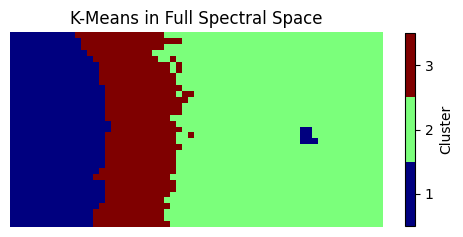

In [ ]:
# Example: cluster the full spectra

k = 3

model = KMeans(n_clusters=k, random_state=0, n_init=10)
labels_high = model.fit_predict(X_scaled)

cluster_map_high = labels_high.reshape(H, W) + 1

plt.figure(figsize=(6, 5))

im = plt.imshow(
    cluster_map_high,
    cmap=plt.get_cmap("jet", k),
    vmin=0.5,
    vmax=k + 0.5
)

plt.colorbar(im, ticks=range(1, k + 1), label="Cluster", shrink = 0.5)
plt.title("K-Means in Full Spectral Space")
plt.axis("off")
plt.show()

<h3>What did we just do?</h3>

<p>
Each EELS spectrum originally contained <b>N<sub>E</sub> spectral features</b>.
</p>

<p>
K-Means therefore grouped the spectra directly in an
<b>N<sub>E</sub>-dimensional feature space</b>.
</p>

<p>
The resulting cluster map is our
<b>high-dimensional clustering result</b>.
</p>

<p>
Next, we will reduce the dimensionality of the spectra and ask:
</p>

<p style="font-size:18px;">
<b>Do we recover the same clustering using fewer features?</b>
</p>

# <font color="red">Challenge 1</font> — High-Dimensional Clustering

Choose a number of clusters and cluster the **full standardized spectra**.

Try values such as:

- \(k=2\)
- \(k=3\)
- \(k=4\)
- \(k=5\)

### Question

> Does the cluster map form physically meaningful spatial regions, or does it look fragmented/noisy?

In [ ]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================

import warnings
from itertools import combinations

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

k = 4  # Start here; rerun this cell and the plot for k = 3, 4, 5.

# Validate the FULL standardized spectra without modifying X_scaled.
X_high = np.asarray(X_scaled)

if X_high.ndim != 2 or X_high.shape != (H * W, N_E):
    raise ValueError("X_scaled must have shape (H * W, N_E).")

if not np.issubdtype(X_high.dtype, np.number) or np.iscomplexobj(X_high):
    raise ValueError("X_scaled must contain real numeric values.")

if not np.isfinite(X_high).all():
    raise ValueError(
        "X_scaled contains NaN or infinity; inspect preprocessing."
    )

if isinstance(k, (bool, np.bool_)) or not isinstance(k, (int, np.integer)):
    raise ValueError("k must be an integer.")

if not 2 <= k < X_high.shape[0]:
    raise ValueError(
        "k must be between 2 and the number of spectra minus 1."
    )

# Five seed batches x five starts = 25 total initializations.
# Keeping each batch winner lets us check initialization stability.
# No PCA, spatial coordinates, smoothing, or extra normalization.
models_high = []

for seed in range(5):
    fitted = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=5,
        max_iter=500,
        tol=1e-4,
        random_state=seed,
        algorithm="lloyd",
        copy_x=True,
    ).fit(X_high)

    models_high.append(fitted)

# Select the lowest-inertia solution for THIS k, not across different k.
model_high = min(models_high, key=lambda fitted: fitted.inertia_)

labels_high = model_high.labels_.copy()           # 0, ..., k - 1
cluster_map_high = labels_high.reshape(H, W) + 1  # 1, ..., k for plotting

counts_high = np.bincount(labels_high, minlength=k)

if np.any(counts_high == 0):
    raise RuntimeError(
        "Fewer than k clusters were found; inspect the data or reduce k."
    )

if any(fitted.n_iter_ >= fitted.max_iter for fitted in models_high):
    warnings.warn(
        "A retained fit reached max_iter; increase it and recheck stability."
    )

# ARI ignores arbitrary cluster-number permutations.
# This checks initialization stability, NOT experimental reproducibility.
stability_ari_high = np.array([
    adjusted_rand_score(first.labels_, second.labels_)
    for first, second in combinations(models_high, 2)
])

# Spatial diagnostics AFTER fitting; they never alter the assignments.
# Use horizontal/vertical neighbors only, counting each pair once.
grid_high = labels_high.reshape(H, W)

same_h = grid_high[:, 1:] == grid_high[:, :-1]
same_v = grid_high[1:, :] == grid_high[:-1, :]

n_pairs = same_h.size + same_v.size

neighbor_agreement_high = (
    np.count_nonzero(same_h) + np.count_nonzero(same_v)
) / n_pairs

# Exact expected neighbor agreement under random shuffling with fixed
# cluster counts: sum_c n_c * (n_c - 1) / [N * (N - 1)].
n_pixels = labels_high.size
counts_float = counts_high.astype(np.float64)

chance_agreement_high = np.sum(
    counts_float * (counts_float - 1)
) / (n_pixels * (n_pixels - 1))

spatial_agreement_high = (
    neighbor_agreement_high - chance_agreement_high
) / (1 - chance_agreement_high)

# A singleton has no same-cluster neighbor above/below/left/right.
same_degree = np.zeros((H, W), dtype=np.uint8)

same_degree[:, 1:] += same_h
same_degree[:, :-1] += same_h
same_degree[1:, :] += same_v
same_degree[:-1, :] += same_v

isolated_high = same_degree.ravel() == 0

singleton_counts_high = np.bincount(
    labels_high[isolated_high],
    minlength=k,
)

# Store diagnostics without selecting k from a hand-weighted score.
diagnostics_high = {
    "k": int(k),
    "inertia": float(model_high.inertia_),
    "initialization_ARI_median": float(np.median(stability_ari_high)),
    "initialization_ARI_min": float(stability_ari_high.min()),
    "neighbor_agreement": float(neighbor_agreement_high),
    "chance_adjusted_neighbor_agreement": float(spatial_agreement_high),
    "singleton_fraction": float(isolated_high.mean()),
    "cluster_sizes": counts_high.copy(),
}

print(
    f"Full-spectrum K-Means: {n_pixels:,} spectra, "
    f"{N_E:,} channels, k={k}"
)
print(
    f"Initialization ARI: median={np.median(stability_ari_high):.3f}, "
    f"minimum={stability_ari_high.min():.3f}"
)
print(
    f"Neighbor agreement: {neighbor_agreement_high:.1%} "
    f"(random-shuffle expectation: {chance_agreement_high:.1%})"
)
print(
    f"Chance-adjusted neighbor agreement: "
    f"{spatial_agreement_high:.3f}"
)
print(f"Single-pixel regions: {isolated_high.mean():.1%}")

for label, count in enumerate(counts_high):
    print(
        f"  Cluster {label + 1}: {count:,} pixels "
        f"({count / n_pixels:.1%}); "
        f"singletons within cluster: "
        f"{singleton_counts_high[label] / count:.1%}"
    )

# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

Full-spectrum K-Means: 2,079 spectra, 4,322 channels, k=4
Initialization ARI: median=0.998, minimum=0.997
Neighbor agreement: 89.8% (random-shuffle expectation: 36.1%)
Chance-adjusted neighbor agreement: 0.841
Single-pixel regions: 0.2%
  Cluster 1: 427 pixels (20.5%); singletons within cluster: 0.5%
  Cluster 2: 1,109 pixels (53.3%); singletons within cluster: 0.2%
  Cluster 3: 262 pixels (12.6%); singletons within cluster: 0.0%
  Cluster 4: 281 pixels (13.5%); singletons within cluster: 0.0%


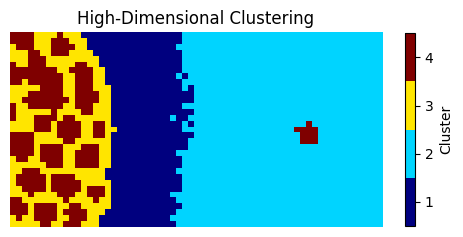

In [ ]:
# Plot your result

plt.figure(figsize=(6, 5))

plt.imshow(
    cluster_map_high,
    cmap=plt.get_cmap("jet", k),
    vmin=0.5,
    vmax=k + 0.5
)

plt.colorbar(
    ticks=range(1, k + 1),
    label="Cluster", shrink = .5
)

plt.title("High-Dimensional Clustering")
plt.axis("off")
plt.show()

<h2><font color="purple">5.</font> Dimensional Reduction with PCA</h2>

<p>
EELS spectra can contain a large number of energy channels.
Many of these channels are correlated, meaning they do not all provide completely independent information.
</p>

<p>
<b>Principal Component Analysis (PCA)</b> reduces the dimensionality of the spectra by representing them with a smaller number of new features called <b>principal components</b>.
</p>

<p>
Instead of describing each spectrum using:
</p>

<p style="font-size:18px;">
N<sub>E</sub> spectral features
</p>

<p>
we can describe it using only:
</p>

<p style="font-size:18px;">
PC<sub>1</sub>, PC<sub>2</sub>, ..., PC<sub>n</sub>
</p>

<p>
The goal is to use fewer dimensions while preserving as much of the important spectral variation as possible.
</p>

<p>
This gives us a <b>low-dimensional representation</b> of the original EELS spectra.
</p>

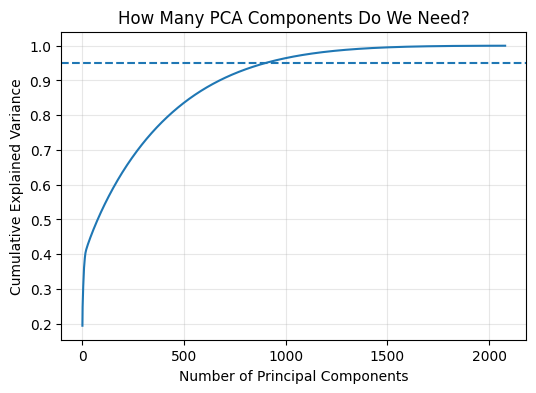

In [ ]:
# First inspect how much information PCA keeps

pca_all = PCA()
pca_all.fit(X_scaled)

variance = np.cumsum(pca_all.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(variance) + 1), variance)
plt.axhline(0.95, linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("How Many PCA Components Do We Need?")
plt.grid(alpha=0.3)
plt.show()

The full standardized EELS spectra produce spatially organized clusters rather than random pixel-level fragmentation. Increasing the number of clusters reveals progressively finer spectral structure. Solutions from \(k=2\) through \(k=4\) are highly reproducible across K-Means initializations, while \(k=5\) shows a pronounced loss of stability. We therefore use \(k=4\) as the high-dimensional reference because it captures additional spatial heterogeneity while remaining robust to initialization.

# <font color="red">Challenge 2</font> — Low-Dimensional Clustering

Choose a small number of PCA components.

For example:

```python
n_components = 3
```

Then:

1. reduce the spectra with PCA,
2. cluster the reduced data with K-Means,
3. reshape the labels into an image.

### Question

> Can a few PCA components reproduce the structure found using the full spectrum?

In [ ]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================

from itertools import combinations

# Keep the same cluster count selected in Challenge 1.
k = 4

# Start with a genuinely low-dimensional representation.
# We can test 2, 5, 10, ... later if needed.
n_components = 3


# ------------------------------------------------------------
# 1. Validate inputs
# ------------------------------------------------------------

X_low_input = np.asarray(X_scaled)

if X_low_input.ndim != 2 or X_low_input.shape != (H * W, N_E):
    raise ValueError("X_scaled must have shape (H * W, N_E).")

if not np.isfinite(X_low_input).all():
    raise ValueError("X_scaled contains NaN or infinity.")

if not 1 <= n_components < min(X_low_input.shape):
    raise ValueError(
        "n_components must be >= 1 and smaller than "
        "min(n_samples, n_features)."
    )


# ------------------------------------------------------------
# 2. PCA dimensional reduction
# ------------------------------------------------------------
# Randomized SVD is efficient when only a few PCs are required.
#
# whiten=False is intentional:
# we want PCA to preserve the variance weighting of the original
# standardized spectral space.

pca = PCA(
    n_components=n_components,
    svd_solver="randomized",
    whiten=False,
    random_state=0,
)

X_pca = pca.fit_transform(X_low_input)

# Make array C-contiguous for efficient K-Means calculations.
X_pca = np.ascontiguousarray(X_pca)

explained_each = pca.explained_variance_ratio_
explained_total = explained_each.sum()


# ------------------------------------------------------------
# 3. K-Means in PCA space
# ------------------------------------------------------------
# Match the Challenge 1 fitting strategy:
# 5 seed batches × 5 initializations = 25 starts total.

models_low = []

for seed in range(5):
    fitted = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=5,
        max_iter=500,
        tol=1e-4,
        random_state=seed,
        algorithm="lloyd",
        copy_x=True,
    ).fit(X_pca)

    models_low.append(fitted)

# Keep the lowest-inertia solution for this representation.
model_low = min(models_low, key=lambda fitted: fitted.inertia_)

labels_low = model_low.labels_.copy()            # 0, ..., k - 1
cluster_map_low = labels_low.reshape(H, W) + 1   # 1, ..., k for plotting


# ------------------------------------------------------------
# 4. Initialization stability
# ------------------------------------------------------------

stability_ari_low = np.array([
    adjusted_rand_score(first.labels_, second.labels_)
    for first, second in combinations(models_low, 2)
])


# ------------------------------------------------------------
# 5. Internal clustering diagnostics
# ------------------------------------------------------------

silhouette_low = silhouette_score(X_pca, labels_low)
davies_bouldin_low = davies_bouldin_score(X_pca, labels_low)

counts_low = np.bincount(labels_low, minlength=k)


# ------------------------------------------------------------
# 6. Spatial coherence diagnostics
# ------------------------------------------------------------
# Spatial coordinates are NOT used for clustering.
# They are used only afterward to evaluate the resulting map.

grid_low = labels_low.reshape(H, W)

same_h = grid_low[:, 1:] == grid_low[:, :-1]
same_v = grid_low[1:, :] == grid_low[:-1, :]

n_pairs = same_h.size + same_v.size

neighbor_agreement_low = (
    np.count_nonzero(same_h)
    + np.count_nonzero(same_v)
) / n_pairs

n_pixels = labels_low.size
counts_float = counts_low.astype(np.float64)

chance_agreement_low = np.sum(
    counts_float * (counts_float - 1)
) / (n_pixels * (n_pixels - 1))

spatial_agreement_low = (
    neighbor_agreement_low - chance_agreement_low
) / (1 - chance_agreement_low)


# Identify isolated single-pixel regions.
same_degree = np.zeros((H, W), dtype=np.uint8)

same_degree[:, 1:] += same_h
same_degree[:, :-1] += same_h
same_degree[1:, :] += same_v
same_degree[:-1, :] += same_v

isolated_low = same_degree.ravel() == 0

singleton_counts_low = np.bincount(
    labels_low[isolated_low],
    minlength=k,
)


# ------------------------------------------------------------
# 7. Store and report diagnostics
# ------------------------------------------------------------

diagnostics_low = {
    "k": int(k),
    "n_components": int(n_components),
    "explained_variance": float(explained_total),
    "silhouette": float(silhouette_low),
    "davies_bouldin": float(davies_bouldin_low),
    "initialization_ARI_median": float(np.median(stability_ari_low)),
    "initialization_ARI_min": float(stability_ari_low.min()),
    "neighbor_agreement": float(neighbor_agreement_low),
    "chance_adjusted_neighbor_agreement": float(spatial_agreement_low),
    "singleton_fraction": float(isolated_low.mean()),
    "cluster_sizes": counts_low.copy(),
}

print(
    f"PCA: {N_E:,} channels -> {n_components} components"
)

print(
    f"Explained variance retained: "
    f"{explained_total:.2%}"
)

print(
    "Variance by PC: "
    + ", ".join(
        f"PC{i + 1}={variance:.2%}"
        for i, variance in enumerate(explained_each)
    )
)

print(
    f"\nLow-dimensional K-Means: "
    f"{n_pixels:,} spectra, {n_components} PCs, k={k}"
)

print(
    f"Initialization ARI: "
    f"median={np.median(stability_ari_low):.3f}, "
    f"minimum={stability_ari_low.min():.3f}"
)

print(
    f"Silhouette score: {silhouette_low:.3f}"
)

print(
    f"Davies-Bouldin index: {davies_bouldin_low:.3f}"
)

print(
    f"Neighbor agreement: {neighbor_agreement_low:.1%} "
    f"(random-shuffle expectation: {chance_agreement_low:.1%})"
)

print(
    f"Chance-adjusted neighbor agreement: "
    f"{spatial_agreement_low:.3f}"
)

print(
    f"Single-pixel regions: {isolated_low.mean():.1%}"
)

for label, count in enumerate(counts_low):
    print(
        f"  Cluster {label + 1}: {count:,} pixels "
        f"({count / n_pixels:.1%}); "
        f"singletons within cluster: "
        f"{singleton_counts_low[label] / count:.1%}"
    )


# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

PCA: 4,322 channels -> 3 components
Explained variance retained: 27.17%
Variance by PC: PC1=19.41%, PC2=5.41%, PC3=2.34%

Low-dimensional K-Means: 2,079 spectra, 3 PCs, k=4
Initialization ARI: median=0.992, minimum=0.992
Silhouette score: 0.452
Davies-Bouldin index: 0.892
Neighbor agreement: 89.8% (random-shuffle expectation: 36.0%)
Chance-adjusted neighbor agreement: 0.840
Single-pixel regions: 0.4%
  Cluster 1: 414 pixels (19.9%); singletons within cluster: 1.0%
  Cluster 2: 292 pixels (14.0%); singletons within cluster: 0.0%
  Cluster 3: 1,109 pixels (53.3%); singletons within cluster: 0.5%
  Cluster 4: 264 pixels (12.7%); singletons within cluster: 0.0%


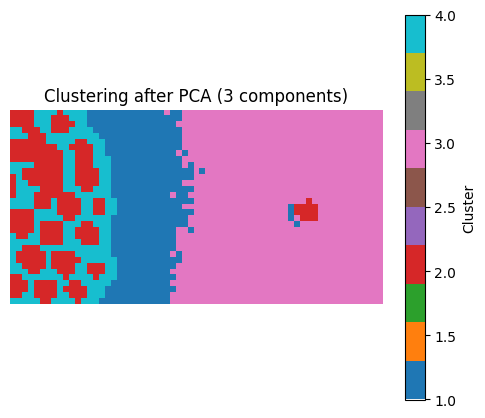

In [ ]:
# Plot your PCA clustering result

plt.figure(figsize=(6, 5))
plt.imshow(cluster_map_low, cmap="tab10")
plt.colorbar(label="Cluster")
plt.title(f"Clustering after PCA ({n_components} components)")
plt.axis("off")
plt.show()

## <font color="purple">**6.**</font> Compare High- and Low-Dimensional Results

Visual comparison is useful, but cluster labels can be misleading.

For example:

- high-dimensional cluster `0`
- low-dimensional cluster `2`

may represent the **same physical group**.

Therefore, do **not** compare cluster numbers directly.

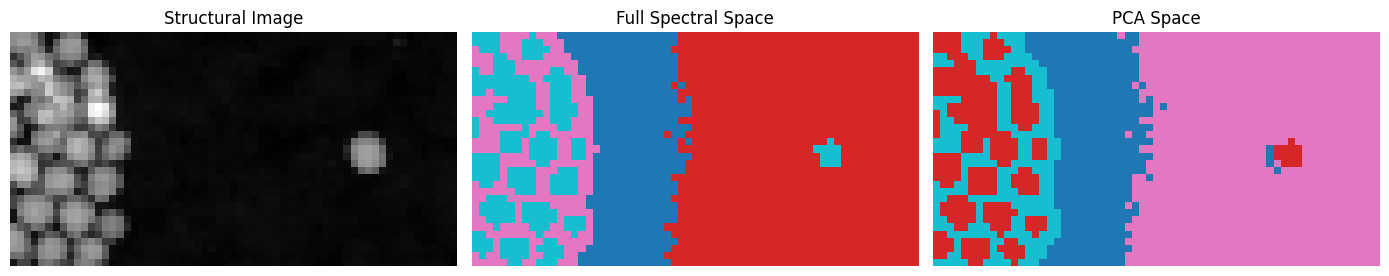

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

ax[0].imshow(image, cmap="gray")
ax[0].set_title("Structural Image")

ax[1].imshow(cluster_map_high, cmap="tab10")
ax[1].set_title("Full Spectral Space")

ax[2].imshow(cluster_map_low, cmap="tab10")
ax[2].set_title("PCA Space")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

Yes. Three PCA components appear sufficient to reproduce the major spatial structure obtained from clustering the full standardized EELS spectra. Although the first three components retain only 27.17% of the total variance, the PCA-space clustering remains highly stable and gives nearly identical spatial-coherence statistics and cluster populations to the full-spectrum solution. This suggests that the spectral variation defining the four clusters is concentrated strongly within the leading principal components.

# <font color="red">Challenge 3</font> — How Much Do the Labels Overlap?

We need a comparison that is independent of the numerical cluster labels.

We will use the **Adjusted Rand Index (ARI)**.

\[
ARI \approx 1
\]

means the two clusterings assign points to very similar groups.

\[
ARI \approx 0
\]

means their agreement is close to random.

The **contingency matrix** also shows how clusters from one solution map onto clusters from the other.

In [ ]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================

from scipy.optimize import linear_sum_assignment

# ------------------------------------------------------------
# 1. Validate the two label sets
# ------------------------------------------------------------

labels_high_compare = np.asarray(labels_high).ravel()
labels_low_compare = np.asarray(labels_low).ravel()

expected_pixels = H * W

if labels_high_compare.size != expected_pixels:
    raise ValueError(
        f"labels_high has {labels_high_compare.size} entries; "
        f"expected {expected_pixels}."
    )

if labels_low_compare.size != expected_pixels:
    raise ValueError(
        f"labels_low has {labels_low_compare.size} entries; "
        f"expected {expected_pixels}."
    )

high_clusters = np.unique(labels_high_compare)
low_clusters = np.unique(labels_low_compare)

if len(high_clusters) != k:
    raise ValueError(
        f"High-dimensional result contains {len(high_clusters)} clusters, "
        f"but k={k}. Make sure Challenge 1 was rerun with k={k}."
    )

if len(low_clusters) != k:
    raise ValueError(
        f"PCA result contains {len(low_clusters)} clusters, "
        f"but k={k}."
    )


# ------------------------------------------------------------
# 2. Adjusted Rand Index
# ------------------------------------------------------------
# ARI is invariant to arbitrary cluster-number permutations.

ari = adjusted_rand_score(
    labels_high_compare,
    labels_low_compare
)


# ------------------------------------------------------------
# 3. Contingency / overlap matrix
# ------------------------------------------------------------
# Rows    = full-spectrum clusters
# Columns = PCA-space clusters

overlap = contingency_matrix(
    labels_high_compare,
    labels_low_compare,
    sparse=False
)


# ------------------------------------------------------------
# 4. Normalize overlap by each full-spectrum cluster
# ------------------------------------------------------------
# Useful for seeing what fraction of each high-dimensional
# cluster is recovered by each PCA cluster.

overlap_fraction = (
    overlap
    / overlap.sum(axis=1, keepdims=True)
)


# ------------------------------------------------------------
# 5. Find the best one-to-one label correspondence
# ------------------------------------------------------------
# Cluster numbers are arbitrary.
# Hungarian matching finds the relabeling that maximizes
# the number of pixels assigned to corresponding groups.

row_ind, col_ind = linear_sum_assignment(-overlap)

matched_pixels = overlap[row_ind, col_ind].sum()

matched_fraction = (
    matched_pixels / expected_pixels
)

# PCA cluster -> corresponding full-spectrum cluster
# +1 only makes the displayed cluster numbers human-readable.
cluster_mapping = {
    int(low_clusters[col]) + 1: int(high_clusters[row]) + 1
    for row, col in zip(row_ind, col_ind)
}


# ============================================================
# YOUR CODE ENDS HERE
# ============================================================
print(f"Adjusted Rand Index: {ari:.3f}")

print("\nCluster overlap matrix:")
print(overlap)
print("\nOverlap fraction by full-spectrum cluster:")
print(np.round(overlap_fraction, 3))

print("\nBest PCA -> full-spectrum cluster mapping:")
for low_cluster, high_cluster in sorted(cluster_mapping.items()):
    print(
        f"  PCA Cluster {low_cluster} "
        f"-> Full Cluster {high_cluster}"
    )

print(
    f"\nBest-matched pixel agreement: "
    f"{matched_fraction:.2%}"
)

Adjusted Rand Index: 0.956

Cluster overlap matrix:
[[ 407    0    8   12]
 [   7    1 1101    0]
 [   0   16    0  246]
 [   0  275    0    6]]

Overlap fraction by full-spectrum cluster:
[[0.953 0.    0.019 0.028]
 [0.006 0.001 0.993 0.   ]
 [0.    0.061 0.    0.939]
 [0.    0.979 0.    0.021]]

Best PCA -> full-spectrum cluster mapping:
  PCA Cluster 1 -> Full Cluster 1
  PCA Cluster 2 -> Full Cluster 4
  PCA Cluster 3 -> Full Cluster 2
  PCA Cluster 4 -> Full Cluster 3

Best-matched pixel agreement: 97.59%


The PCA-space clustering strongly reproduces the full-spectrum clustering. The Adjusted Rand Index is 0.956, indicating very high agreement independent of arbitrary cluster numbering. After optimally matching the cluster labels, 97.59% of all pixels are assigned to corresponding groups. Individual full-spectrum clusters are recovered at approximately 94–99%, showing that reducing the 4,322-channel spectra to only three principal components preserves nearly all of the cluster structure identified in the original standardized spectral space. This agreement demonstrates preservation of the clustering structure, but it does not by itself establish that the clusters correspond to distinct physical phases or mechanisms. Spectral and structural interpretation is still required.

<h2><font color="purple">7.</font> What Makes Clustering Good or Bad?</h2>

<p>
In unsupervised clustering, we usually do not have ground-truth labels.
Therefore, we evaluate clustering using <b>internal quality metrics</b>.
</p>

<p>Here we will use two common metrics:</p>

<hr>

<h3>Silhouette Score</h3>

<p>
The Silhouette Score measures how well each point fits within its assigned cluster.
A good point should be:
</p>

<ul>
  <li>close to other points in the <b>same cluster</b></li>
  <li>far from points in <b>neighboring clusters</b></li>
</ul>

<p><b>Range:</b></p>

<p style="font-size:18px;">
-1 &le; S &le; 1
</p>

<ul>
  <li><b>Higher is better</b></li>
  <li>Values near 1 indicate well-separated clusters</li>
  <li>Values near 0 indicate overlapping clusters</li>
  <li>Negative values may indicate poor assignments</li>
</ul>

<hr>

<h3>Davies–Bouldin Score</h3>

<p>
The Davies–Bouldin Score measures how compact the clusters are
and how well separated they are from each other.
</p>

<p><b>Range:</b></p>

<p style="font-size:18px;">
DB &ge; 0
</p>

<ul>
  <li><b>Lower is better</b></li>
  <li>Smaller values indicate compact, well-separated clusters</li>
</ul>

<hr>

<p>
<b>Important:</b> A good numerical clustering score does not automatically mean
that the clusters are physically meaningful.
</p>

<p>
For EELS data, we should also inspect the spatial cluster maps and the average
spectrum of each cluster.
</p>

# <font color="red">Challenge 4</font> — Score Both Clusterings

Calculate the clustering quality in:

1. the full spectral space,
2. the PCA-reduced space.

### Important

Evaluate each set of labels in the **same feature space in which it was clustered**.

In [ ]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================

# ------------------------------------------------------------
# Validate inputs
# ------------------------------------------------------------

X_high_score = np.asarray(X_scaled)
X_low_score = np.asarray(X_pca)

labels_high_score = np.asarray(labels_high).ravel()
labels_low_score = np.asarray(labels_low).ravel()

n_samples = H * W

if X_high_score.shape[0] != n_samples:
    raise ValueError(
        "X_scaled and the spatial image contain different "
        "numbers of samples."
    )

if X_low_score.shape[0] != n_samples:
    raise ValueError(
        "X_pca and the spatial image contain different "
        "numbers of samples."
    )

if labels_high_score.size != n_samples:
    raise ValueError("labels_high has the wrong number of entries.")

if labels_low_score.size != n_samples:
    raise ValueError("labels_low has the wrong number of entries.")

if np.unique(labels_high_score).size < 2:
    raise ValueError(
        "Silhouette and Davies-Bouldin require at least 2 clusters."
    )

if np.unique(labels_low_score).size < 2:
    raise ValueError(
        "Silhouette and Davies-Bouldin require at least 2 clusters."
    )


# ------------------------------------------------------------
# High-dimensional clustering
# ------------------------------------------------------------
# Evaluate labels_high in the SAME 4,322-dimensional standardized
# feature space used to obtain those labels.

sil_high = silhouette_score(
    X_high_score,
    labels_high_score,
    metric="euclidean"
)

db_high = davies_bouldin_score(
    X_high_score,
    labels_high_score
)


# ------------------------------------------------------------
# Low-dimensional clustering
# ------------------------------------------------------------
# Evaluate labels_low in the SAME 3-dimensional PCA space
# used to obtain those labels.

sil_low = silhouette_score(
    X_low_score,
    labels_low_score,
    metric="euclidean"
)

db_low = davies_bouldin_score(
    X_low_score,
    labels_low_score
)


# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

print("Full spectral space")
print(f"  Silhouette:      {sil_high:.3f}")
print(f"  Davies-Bouldin:  {db_high:.3f}")

print("\nPCA space")
print(f"  Silhouette:      {sil_low:.3f}")
print(f"  Davies-Bouldin:  {db_low:.3f}")

Full spectral space
  Silhouette:      0.074
  Davies-Bouldin:  3.239

PCA space
  Silhouette:      0.452
  Davies-Bouldin:  0.892


The PCA representation produces substantially more compact and separated clusters than the full standardized spectral space. The silhouette score increases from 0.074 to 0.452, while the Davies–Bouldin index decreases from 3.239 to 0.892. Combined with the high full-vs-PCA ARI of 0.956 and 97.59% matched pixel agreement, this indicates that the leading three principal components preserve the spectral structure responsible for the clustering while suppressing much of the variation that obscures cluster separation in the original high-dimensional space.

## <font color="purple">**8.**</font> Inspect the Average Spectrum of Each Cluster

A clustering map is much easier to interpret if the clusters also have distinct spectral signatures.

For every cluster, calculate the **mean EELS spectrum**.

### Question

> Do the clusters differ in peak intensity, peak position, spectral shape, or background?

In [ ]:
# Example helper function

def plot_cluster_spectra(X, labels, energy):
    for label in np.unique(labels):
        mean_spectrum = X[labels == label].mean(axis=0)
        plt.plot(energy, mean_spectrum, label=f"Cluster {label}")

    plt.xlabel("Energy")
    plt.ylabel("Mean EELS Intensity")
    plt.title("Mean Spectrum of Each Cluster")
    plt.legend()
    plt.show()

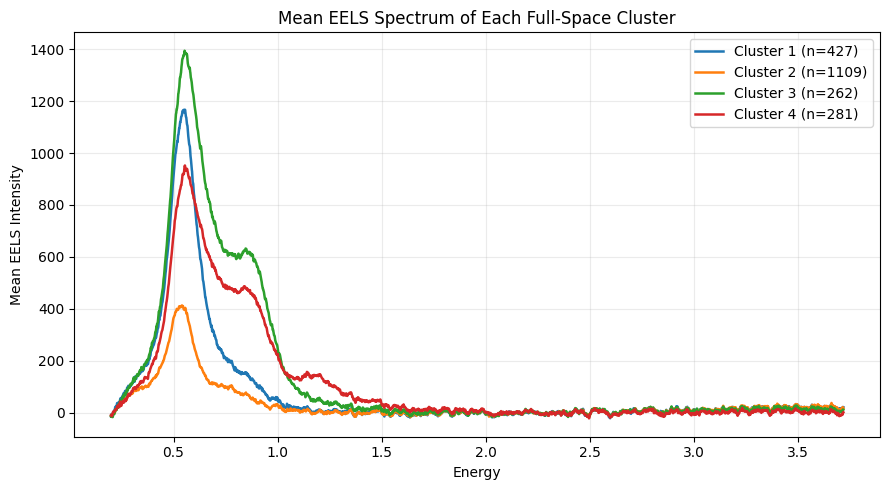

Mean-spectrum populations:
  Cluster 1: 427 spectra
  Cluster 2: 1,109 spectra
  Cluster 3: 262 spectra
  Cluster 4: 281 spectra


In [ ]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================

# ------------------------------------------------------------
# Use the original, unstandardized EELS spectra
# ------------------------------------------------------------

X_original = np.asarray(X)
energy_axis = np.asarray(energy).ravel()
labels_spectra = np.asarray(labels_high).ravel()

# Basic validation
if X_original.ndim != 2:
    raise ValueError("X must be a 2D matrix of spectra.")

if X_original.shape != (H * W, N_E):
    raise ValueError(
        f"X has shape {X_original.shape}; "
        f"expected {(H * W, N_E)}."
    )

if energy_axis.size != N_E:
    raise ValueError(
        f"Energy axis has {energy_axis.size} values; "
        f"expected {N_E}."
    )

if labels_spectra.size != X_original.shape[0]:
    raise ValueError(
        "labels_high and X contain different numbers of spectra."
    )

if not np.isfinite(X_original).all():
    raise ValueError("X contains NaN or infinity.")

if not np.isfinite(energy_axis).all():
    raise ValueError("energy contains NaN or infinity.")


# ------------------------------------------------------------
# Calculate mean and spread of each cluster
# ------------------------------------------------------------

cluster_ids = np.unique(labels_spectra)

cluster_mean_spectra = {}
cluster_std_spectra = {}
cluster_sizes_spectra = {}

for label in cluster_ids:

    cluster_data = X_original[labels_spectra == label]

    cluster_mean_spectra[label] = cluster_data.mean(axis=0)
    cluster_std_spectra[label] = cluster_data.std(axis=0, ddof=1)
    cluster_sizes_spectra[label] = cluster_data.shape[0]


# ------------------------------------------------------------
# Plot the physically interpretable mean EELS spectra
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

for label in cluster_ids:

    mean_spectrum = cluster_mean_spectra[label]
    n_cluster = cluster_sizes_spectra[label]

    # +1 makes displayed cluster numbers match our cluster maps.
    plt.plot(
        energy_axis,
        mean_spectrum,
        linewidth=1.8,
        label=f"Cluster {label + 1} (n={n_cluster})"
    )

plt.xlabel("Energy")
plt.ylabel("Mean EELS Intensity")
plt.title("Mean EELS Spectrum of Each Full-Space Cluster")

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Report cluster sizes
# ------------------------------------------------------------

print("Mean-spectrum populations:")

for label in cluster_ids:
    print(
        f"  Cluster {label + 1}: "
        f"{cluster_sizes_spectra[label]:,} spectra"
    )


# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

# <font color="red">Final Challenge</font> — Find a Good Clustering

Systematically test different choices.

You may change:

- number of clusters \(k\)
- number of PCA components

For each experiment, record:

- \(k\)
- PCA dimensions
- explained variance
- Silhouette score
- Davies–Bouldin score
- ARI compared with the full-space clustering

### Your goal

> Find a low-dimensional representation that gives compact, separated clusters while preserving the grouping found in the original spectral space.

In [ ]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================

import pandas as pd
from itertools import combinations


# ------------------------------------------------------------
# 1. Search space
# ------------------------------------------------------------

k_values = [2, 3, 4, 5]

# Include 1 PC so we can determine the actual lower limit.
component_values = [1, 2, 3, 5, 10]


# ------------------------------------------------------------
# 2. Fixed full-spectrum reference
# ------------------------------------------------------------
# Challenge 1 selected k=4 as the full-dimensional reference.
# Every low-dimensional experiment is compared to THIS partition.

reference_labels = np.asarray(labels_high).ravel()
reference_k = np.unique(reference_labels).size

if reference_k != 4:
    raise ValueError(
        f"labels_high currently contains {reference_k} clusters. "
        "Rerun Challenge 1 with k=4 before the final search."
    )

if reference_labels.size != H * W:
    raise ValueError(
        "labels_high does not contain one label per spatial pixel."
    )

X_search = np.asarray(X_scaled)

if X_search.shape != (H * W, N_E):
    raise ValueError(
        f"X_scaled has shape {X_search.shape}; "
        f"expected {(H * W, N_E)}."
    )

if not np.isfinite(X_search).all():
    raise ValueError("X_scaled contains NaN or infinity.")


# ------------------------------------------------------------
# 3. Helper: robust K-Means fitting
# ------------------------------------------------------------
# Same strategy used in Challenges 1 and 2:
# 5 seed batches x 5 initializations = 25 starts total.
#
# We retain each batch winner so initialization stability can
# also be measured.

def fit_stable_kmeans(X_features, k):

    models = []

    for seed in range(5):

        fitted = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=5,
            max_iter=500,
            tol=1e-4,
            random_state=seed,
            algorithm="lloyd",
            copy_x=True,
        ).fit(X_features)

        models.append(fitted)

    # Best solution among all retained batch winners
    best_model = min(
        models,
        key=lambda fitted: fitted.inertia_
    )

    # Stability across retained solutions
    pairwise_ari = np.array([
        adjusted_rand_score(first.labels_, second.labels_)
        for first, second in combinations(models, 2)
    ])

    return (
        best_model,
        float(np.median(pairwise_ari)),
        float(np.min(pairwise_ari)),
    )


# ------------------------------------------------------------
# 4. Helper: spatial diagnostics
# ------------------------------------------------------------
# Spatial coordinates are used ONLY to evaluate the maps,
# never as clustering features.

def spatial_diagnostics(labels, k):

    labels = np.asarray(labels).ravel()
    grid = labels.reshape(H, W)

    same_h = grid[:, 1:] == grid[:, :-1]
    same_v = grid[1:, :] == grid[:-1, :]

    n_pairs = same_h.size + same_v.size

    neighbor_agreement = (
        np.count_nonzero(same_h)
        + np.count_nonzero(same_v)
    ) / n_pairs

    counts = np.bincount(labels, minlength=k)
    counts_float = counts.astype(np.float64)

    n_pixels = labels.size

    chance_agreement = np.sum(
        counts_float * (counts_float - 1)
    ) / (n_pixels * (n_pixels - 1))

    spatial_adjusted = (
        neighbor_agreement - chance_agreement
    ) / (1.0 - chance_agreement)

    # Identify pixels with no same-cluster N/S/E/W neighbor
    same_degree = np.zeros((H, W), dtype=np.uint8)

    same_degree[:, 1:] += same_h
    same_degree[:, :-1] += same_h
    same_degree[1:, :] += same_v
    same_degree[:-1, :] += same_v

    singleton_fraction = np.mean(
        same_degree.ravel() == 0
    )

    smallest_cluster_fraction = (
        counts.min() / n_pixels
    )

    return (
        float(spatial_adjusted),
        float(singleton_fraction),
        float(smallest_cluster_fraction),
    )


# ------------------------------------------------------------
# 5. Run systematic PCA + K-Means search
# ------------------------------------------------------------

search_results = []

# Save fitted objects so the selected result can be reused later
# without recomputing it.
search_pcas = {}
search_models = {}
search_labels = {}
search_embeddings = {}

for n_components in component_values:

    # Fit PCA once for this dimensionality and reuse it for every k.
    # This also means the n_components=3 experiment uses exactly the
    # same PCA setup as Challenge 2.
    pca_search = PCA(
        n_components=n_components,
        svd_solver="randomized",
        whiten=False,
        random_state=0,
    )

    X_reduced = pca_search.fit_transform(X_search)
    X_reduced = np.ascontiguousarray(X_reduced)

    explained_variance = (
        pca_search.explained_variance_ratio_.sum()
    )

    search_pcas[n_components] = pca_search
    search_embeddings[n_components] = X_reduced

    for k_test in k_values:

        model_test, init_ari_median, init_ari_min = (
            fit_stable_kmeans(
                X_reduced,
                k_test
            )
        )

        labels_test = model_test.labels_.copy()

        # ----------------------------------------------------
        # Required Final Challenge metrics
        # ----------------------------------------------------

        silhouette = silhouette_score(
            X_reduced,
            labels_test,
            metric="euclidean"
        )

        db_score = davies_bouldin_score(
            X_reduced,
            labels_test
        )

        # Always compare against the selected full-space k=4
        # reference partition.
        ari_reference = adjusted_rand_score(
            reference_labels,
            labels_test
        )

        # ----------------------------------------------------
        # Additional robustness / spatial diagnostics
        # ----------------------------------------------------

        (
            spatial_agreement,
            singleton_fraction,
            smallest_cluster_fraction,
        ) = spatial_diagnostics(
            labels_test,
            k_test
        )

        # Save objects for later inspection
        search_models[
            (n_components, k_test)
        ] = model_test

        search_labels[
            (n_components, k_test)
        ] = labels_test

        # Store one result row
        search_results.append({
            "k": k_test,
            "PCA components": n_components,
            "Explained variance (%)":
                100.0 * explained_variance,
            "Silhouette":
                silhouette,
            "Davies-Bouldin":
                db_score,
            "ARI vs full k=4":
                ari_reference,
            "Init ARI median":
                init_ari_median,
            "Init ARI minimum":
                init_ari_min,
            "Spatial agreement":
                spatial_agreement,
            "Singletons (%)":
                100.0 * singleton_fraction,
            "Smallest cluster (%)":
                100.0 * smallest_cluster_fraction,
        })


# ------------------------------------------------------------
# 6. Build final results table
# ------------------------------------------------------------

results_df = pd.DataFrame(search_results)

results_df = results_df.sort_values(
    ["PCA components", "k"]
).reset_index(drop=True)


# Rounded copy for readable display only
results_display = results_df.copy()

rounding = {
    "Explained variance (%)": 2,
    "Silhouette": 3,
    "Davies-Bouldin": 3,
    "ARI vs full k=4": 3,
    "Init ARI median": 3,
    "Init ARI minimum": 3,
    "Spatial agreement": 3,
    "Singletons (%)": 2,
    "Smallest cluster (%)": 2,
}

results_display = results_display.round(rounding)


print("SYSTEMATIC PCA + K-MEANS SEARCH")
print(
    f"Reference: full standardized spectra, "
    f"k={reference_k}"
)

print("\nAll experiments:\n")

print(
    results_display.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 7. Show the k=4 rows separately
# ------------------------------------------------------------
# These are the most direct tests of how many PCs are needed
# to reproduce our selected four-cluster reference.

print("\n\nDIRECT COMPARISON TO SELECTED k=4 SOLUTION:\n")

print(
    results_display[
        results_display["k"] == reference_k
    ].to_string(index=False)
)


# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

SYSTEMATIC PCA + K-MEANS SEARCH
Reference: full standardized spectra, k=4

All experiments:

 k  PCA components  Explained variance (%)  Silhouette  Davies-Bouldin  ARI vs full k=4  Init ARI median  Init ARI minimum  Spatial agreement  Singletons (%)  Smallest cluster (%)
 2               1                   19.41       0.773           0.300            0.518            1.000             1.000              0.972            0.00                 28.81
 3               1                   19.41       0.682           0.448            0.776            0.997             0.991              0.926            0.29                 19.29
 4               1                   19.41       0.630           0.483            0.682            0.984             0.955              0.891            0.67                  9.72
 5               1                   19.41       0.589           0.533            0.596            0.981             0.928              0.834            1.49                  8.99
 2     

## Final Discussion

Be ready to explain your result.

### 1. High vs. low dimensional space
Did PCA change the clustering substantially?

PCA did not substantially change the main clustering structure.

Using only two principal components, representing 24.83% of the total standardized spectral variance, produced an ARI of 0.955 relative to the full 4,322-dimensional \(k=4\) clustering.

That means the major group structure survives a huge reduction:

$$ 4322\text{ dimensions}\rightarrow2\text{ dimensions}. $$

The leading PCA components therefore contain most of the information needed to distinguish these four spectral groups, even though they do not retain most of the total variance.

### 2. Cluster overlap
Was the ARI high or low? What does that tell you?

The overlap is very high.

For our original 3-PC test:

$$ ARI=0.956 $$

with 97.59% best-matched pixel agreement.

The systematic search shows that 2 PCs already achieve ARI = 0.955, essentially identical to the 3-PC result.

This tells us that dimensional reduction preserves nearly all of the grouping found in the full spectral space.

A useful point to emphasize is that ARI is label-independent, so this is not affected by PCA Cluster 1 being called Full-space Cluster 3, etc.

### 3. Quality
Which solution had:

- higher Silhouette score?
- lower Davies–Bouldin score?

The low-dimensional solution is much better according to both internal metrics.

Full spectral space
$$ \text{Silhouette}=0.074 $$ $$ DB=3.239 $$
Selected 2-PC space
$$ \text{Silhouette}=0.572 $$ $$ DB=0.661 $$

Therefore, the PCA representation has the higher Silhouette score and lower Davies–Bouldin index.

The interpretation is that the clusters are substantially more compact and better separated in the reduced space.

This does not mean the discarded dimensions are necessarily noise. It means they contribute variation that is not required—and may obscure Euclidean separation—for this particular four-cluster partition.

### 4. Physics
Do the clusters correspond to:

- spatially coherent regions?
- different EELS spectral signatures?
- visible structural regions?

There is evidence that the clusters are more than arbitrary mathematical labels.

Spatial coherence: Yes. The \(k=4\) full-space result had a chance-adjusted spatial agreement of 0.841, and the 2-PC solution gives 0.843. The cluster maps form organized regions rather than random salt-and-pepper assignments.

Different EELS signatures: Yes. The cluster-average spectra showed substantial differences in the intensity and shape of the low-energy EELS features. The main peak intensity changed strongly between clusters, and the post-peak spectral shapes also differed. There was no obvious large shift of the principal peak based on visual inspection.

Visible structural regions: Broadly, yes. The major spectral regions correspond to features visible in the structural image, including the strongly textured/bright left region, the more uniform right region, and the small localized feature within the right side. Not every fine cluster boundary can be confidently assigned to a structural feature from the image alone, so we should not claim that each cluster necessarily represents a distinct phase.

### 5. Complexity
How many PCA components were actually necessary?

The sweep makes this quite clear.

One PC is insufficient if preserving the full \(k=4\) structure is important:

$$ ARI_{1PC}=0.682. $$

Although one PC produces excellent internal scores:

$$ S=0.630,\qquad DB=0.483, $$

it has simplified the data too aggressively and no longer reproduces the original four-group partition well enough.

With two PCs:

$$ ARI=0.955, $$ $$ S=0.572, $$ $$ DB=0.661. $$

Three PCs barely improve preservation:

$$ 0.955\rightarrow0.956, $$

while making the cluster geometry worse:

$$ S:0.572\rightarrow0.452 $$

and

$$ DB:0.661\rightarrow0.892. $$

Therefore:

$$ \boxed{\textbf{2 PCA components are sufficient}} $$

for this dataset and objective.

## <font color="green">Takeaway</font>

A clustering result is not good simply because an algorithm produced labels.

A useful clustering should ideally be:

- **well separated**
- **internally compact**
- **stable under dimensional reduction**
- **spectrally interpretable**
- **spatially or physically meaningful**

A four-cluster solution in two-dimensional PCA space provides a strong balance between simplicity, cluster separation, stability, and preservation of the original full-spectrum grouping. Two PCA components retain only 24.83% of the total standardized variance but reproduce the full-space \(k=4\) clustering with an ARI of 0.955. The PCA solution also substantially improves the Silhouette score from 0.074 to 0.572 and reduces the Davies–Bouldin index from 3.239 to 0.661. The resulting clusters are spatially coherent and exhibit distinct mean EELS spectral signatures, supporting their physical relevance while stopping short of assigning specific phases or mechanisms without additional evidence.

k=4, PCA=2, ARI=0.955, Silhouette=0.572, DB=0.661
	​
